In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\Baciucu\AC2026\SI\ml_project\sklearn_env\nlp_dataset


In [2]:
import pandas as pd

dataset_path = PROJECT_ROOT / "data" / "final" / "medical_dataset.csv"

df = pd.read_csv(dataset_path)
df.head()

,symptom,disease,treatment_recommendation,source_name,source_url,source_topic,confidence,evidence,model_used,extraction_status,validation_status,validation_notes
0,fever,influenza,"Rest, drink fluids, and seek medical care if s...",MedlinePlus,https://medlineplus.gov/flu.html,flu,0.85,Short quote or paraphrase from the source text.,ollama/llama3.2:3b,extracted,valid,Passed rule-based validation.
1,cough,influenza,Antiviral medicines can make the illness milde...,Centers for Disease Control and Prevention,https://www.cdc.gov/flu/index.html,flu,0.92,CDC website,ollama/llama3.2:3b,extracted,rejected,Dose information and guaranteed cure present i...
2,fever,influenza,"Rest, drink fluids, and seek medical care if s...",MedlinePlus,https://medlineplus.gov/flu.html,flu,0.88,Short quote or paraphrase from the source text.,ollama/llama3.2:3b,extracted,needs_review,Row contains unclear symptom 'fatigue (tiredne...
3,headache,influenza,Antiviral medicines can make the illness milde...,Centers for Disease Control and Prevention,https://www.cdc.gov/flu/index.html,flu,0.91,CDC website,ollama/llama3.2:3b,extracted,rejected,Row rejected due to guaranteed cure and unsafe...
4,muscle or body aches,influenza,"Rest, drink fluids, and seek medical care if s...",MedlinePlus,https://medlineplus.gov/flu.html,flu,0.86,Short quote or paraphrase from the source text.,ollama/llama3.2:3b,extracted,needs_review,Dose information missing.


In [3]:
len(df)

43

In [4]:
df["validation_status"].value_counts()

validation_status
valid           33
needs_review     7
rejected         3
Name: count, dtype: int64

In [5]:
df["source_name"].value_counts()

source_name
MedlinePlus                                                 17
NHS                                                         15
Mayo Clinic                                                  6
Centers for Disease Control and Prevention                   3
National Heart, Lung, and Blood Institute                    1
National Center for Complementary and Integrative Health     1
Name: count, dtype: int64

In [6]:
df["disease"].value_counts().head(10)

disease
influenza         23
asthma             7
common cold        6
osteoarthritis     6
pneumonia          1
Name: count, dtype: int64

In [7]:
df["symptom"].value_counts().head(10)

symptom
fever                    5
headache                 3
sore throat              3
coughing                 3
cough                    2
chest tightness          2
shortness of breath      2
muscle or body aches     1
vomiting and diarrhea    1
runny nose               1
Name: count, dtype: int64

In [8]:
df.isna().sum()

symptom                     0
disease                     0
treatment_recommendation    0
source_name                 0
source_url                  0
source_topic                0
confidence                  0
evidence                    0
model_used                  0
extraction_status           0
validation_status           0
validation_notes            0
dtype: int64

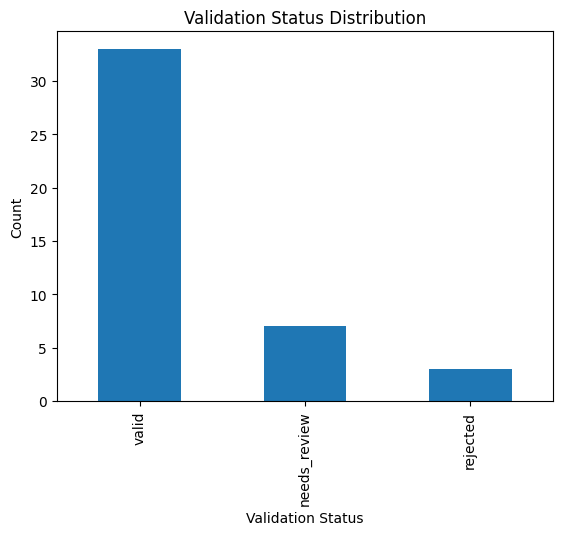

In [9]:
import matplotlib.pyplot as plt

df["validation_status"].value_counts().plot(kind="bar")
plt.title("Validation Status Distribution")
plt.xlabel("Validation Status")
plt.ylabel("Count")
plt.show()

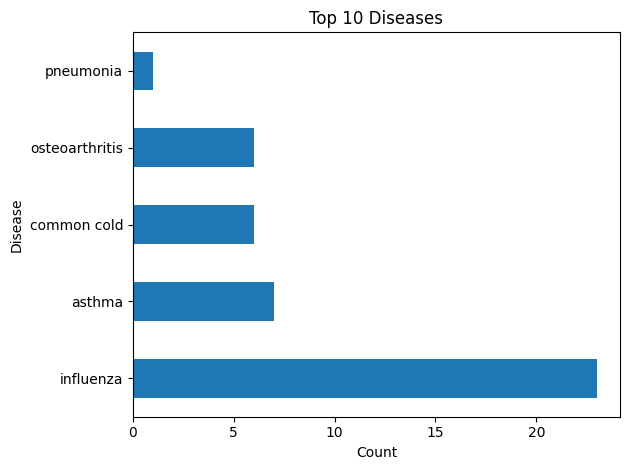

In [10]:
df["disease"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Diseases")
plt.xlabel("Count")
plt.ylabel("Disease")
plt.tight_layout()
plt.savefig("../reports/top_10_diseases.png")
plt.show()

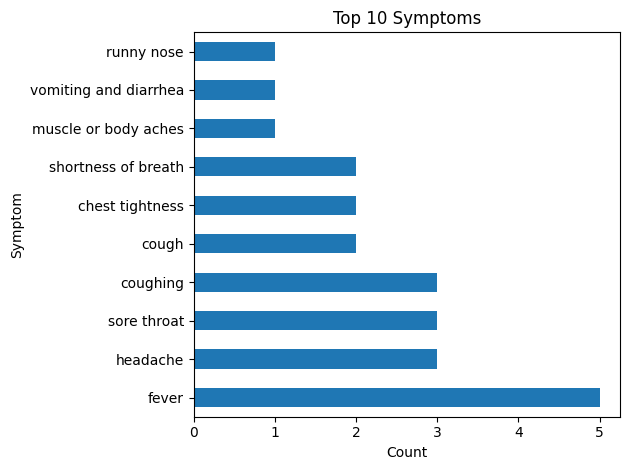

In [11]:
df["symptom"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Symptoms")
plt.xlabel("Count")
plt.ylabel("Symptom")
plt.tight_layout()
plt.savefig("../reports/top_10_symptoms.png")
plt.show()

C:\Users\Baciucu\AppData\Local\Temp\ipykernel_10108\1778234208.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


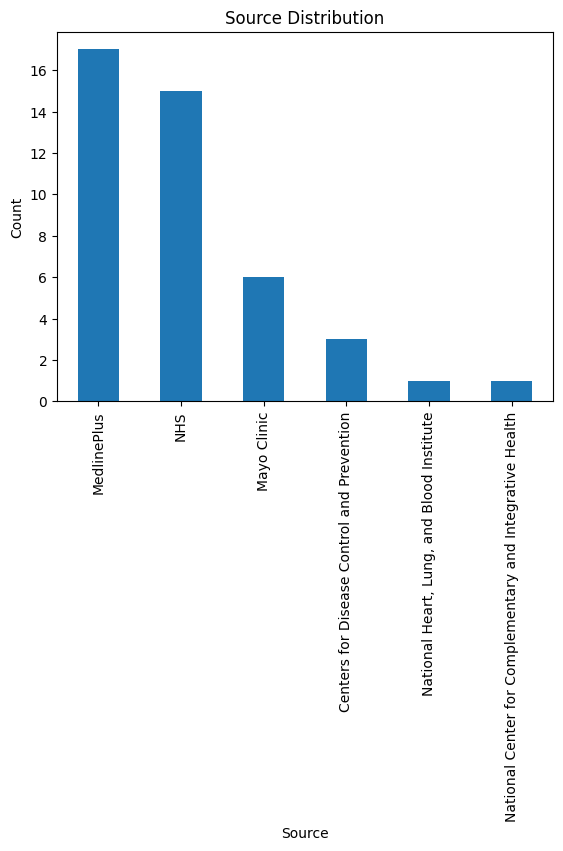

In [12]:
df["source_name"].value_counts().plot(kind="bar")
plt.title("Source Distribution")
plt.xlabel("Source")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/source_distribution.png")
plt.show()

In [13]:
df[df["confidence"] < 0.8][
    ["symptom", "disease", "confidence", "validation_status"]
]

,symptom,disease,confidence,validation_status


In [14]:
df[df["validation_status"] == "needs_review"][
    ["symptom", "disease", "treatment_recommendation", "validation_notes"]
]

,symptom,disease,treatment_recommendation,validation_notes
2,fever,influenza,"Rest, drink fluids, and seek medical care if s...",Row contains unclear symptom 'fatigue (tiredne...
4,muscle or body aches,influenza,"Rest, drink fluids, and seek medical care if s...",Dose information missing.
6,vomiting and diarrhea,influenza,"Rest, drink fluids, and seek medical care if s...",Dose information missing.
8,sore throat,common cold,"Rest, drink fluids, and seek medical care if s...",Dose information is present but not specified....
9,coughing,common cold,"Rest, drink fluids, and seek medical care if s...",Dose information and guaranteed cure are missi...
10,headache,common cold,Getting lots of rest.,treatment too short
14,dehydration,common cold,Drink plenty of fluids.,treatment too short


In [15]:
summary = {
    "total_rows": len(df),
    "unique_symptoms": df["symptom"].nunique(),
    "unique_diseases": df["disease"].nunique(),
    "unique_sources": df["source_name"].nunique(),
    "average_confidence": round(df["confidence"].mean(), 3),
    "valid_rows": int((df["validation_status"] == "valid").sum()),
    "needs_review_rows": int((df["validation_status"] == "needs_review").sum()),
    "rejected_rows": int((df["validation_status"] == "rejected").sum()),
}

summary

{'total_rows': 43,
 'unique_symptoms': 30,
 'unique_diseases': 5,
 'unique_sources': 6,
 'average_confidence': np.float64(0.856),
 'valid_rows': 33,
 'needs_review_rows': 7,
 'rejected_rows': 3}